In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import required libraries and define file paths for loading LoRA and QLoRA final result tables
import os
import pandas as pd

# Define the file paths for LoRA results, QLoRA results, and the comparison output directory
lora_path = "/content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/LORA_OUTPUTS/final_results/lora_final_results_table.csv"
qlora_path = "/content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/QLORA_OUTPUTS/final_results/qlora_final_results_table.csv"

save_dir = "/content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison"
os.makedirs(save_dir, exist_ok=True)

# Load the final results tables for LoRA and QLoRA from CSV files
lora_df = pd.read_csv(lora_path)
qlora_df = pd.read_csv(qlora_path)

# Select the first row from each result table as the summary record for comparison
lora_row = lora_df.iloc[0].copy()
qlora_row = qlora_df.iloc[0].copy()

# Map raw metric column names to cleaner display names for the comparison tables
metric_name_map = {
    "train_loss": "Train Loss",
    "best_metric": "Best Validation Metric",
    "bleu": "BLEU",
    "rouge1": "ROUGE-1",
    "rouge2": "ROUGE-2",
    "rougeL": "ROUGE-L",
    "rougeLsum": "ROUGE-Lsum",
    "bertscore_precision": "BERTScore Precision",
    "bertscore_recall": "BERTScore Recall",
    "bertscore_f1": "BERTScore F1",
    "avg_prediction_token_length": "Avg Prediction Token Length",
    "avg_reference_token_length": "Avg Reference Token Length",
    "prediction_reference_length_ratio": "Prediction / Reference Length Ratio",
    "avg_fact_precision": "Avg Fact Precision",
    "avg_fact_recall": "Avg Fact Recall",
    "avg_fact_f1": "Avg Fact F1",
    "avg_hallucination_rate": "Avg Hallucination Rate",
    "exact_match_rate": "Exact Match Rate",
    "exact_match_count": "Exact Match Count",
    "test_input_overlap_rate": "Test Input Overlap Rate",
    "test_output_overlap_rate": "Test Output Overlap Rate"
}

# Define the preferred order in which comparison metrics should appear
ordered_metrics = [
    "train_loss",
    "best_metric",
    "bleu",
    "rouge1",
    "rouge2",
    "rougeL",
    "rougeLsum",
    "bertscore_precision",
    "bertscore_recall",
    "bertscore_f1",
    "avg_prediction_token_length",
    "avg_reference_token_length",
    "prediction_reference_length_ratio",
    "avg_fact_precision",
    "avg_fact_recall",
    "avg_fact_f1",
    "avg_hallucination_rate",
    "exact_match_rate",
    "exact_match_count",
    "test_input_overlap_rate",
    "test_output_overlap_rate"
]

# Keep only the metrics that are present in both LoRA and QLoRA result tables
available_metrics = [m for m in ordered_metrics if m in lora_row.index and m in qlora_row.index]

# Build the main clean LoRA vs QLoRA comparison table using all available metrics
comparison_rows = []
for metric in available_metrics:
    comparison_rows.append({
        "Metric": metric_name_map.get(metric, metric),
        "LoRA": lora_row[metric],
        "QLoRA": qlora_row[metric]
    })

comparison_table = pd.DataFrame(comparison_rows)

# Display the full LoRA vs QLoRA comparison table
print("LoRA vs QLoRA - Full Comparison Table")
display(comparison_table)

# Save the full comparison table to CSV
main_save_path = os.path.join(save_dir, "lora_vs_qlora_clean_comparison_table.csv")
comparison_table.to_csv(main_save_path, index=False)
print("Saved main comparison table to:", main_save_path)

# Define grouped metric lists for separate focused comparison tables
training_metrics = ["train_loss", "best_metric"]
text_metrics = ["bleu", "rouge1", "rouge2", "rougeL", "rougeLsum", "bertscore_precision", "bertscore_recall", "bertscore_f1"]
length_metrics = ["avg_prediction_token_length", "avg_reference_token_length", "prediction_reference_length_ratio"]
factual_metrics = ["avg_fact_precision", "avg_fact_recall", "avg_fact_f1", "avg_hallucination_rate", "exact_match_rate", "exact_match_count"]
overlap_metrics = ["test_input_overlap_rate", "test_output_overlap_rate"]

# Define a reusable function to build, display, and save grouped comparison tables
def build_group_table(metric_list, title, filename):
    rows = []
    for metric in metric_list:
        if metric in lora_row.index and metric in qlora_row.index:
            rows.append({
                "Metric": metric_name_map.get(metric, metric),
                "LoRA": lora_row[metric],
                "QLoRA": qlora_row[metric]
            })
    df = pd.DataFrame(rows)
    print(f"\n{title}")
    display(df)
    save_path = os.path.join(save_dir, filename)
    df.to_csv(save_path, index=False)
    print("Saved to:", save_path)
    return df

# Build and save the grouped training metrics comparison table
training_table = build_group_table(
    training_metrics,
    "Training Metrics Comparison",
    "training_metrics_comparison.csv"
)

# Build and save the grouped text generation metrics comparison table
text_table = build_group_table(
    text_metrics,
    "Text Generation Metrics Comparison",
    "text_generation_metrics_comparison.csv"
)

# Build and save the grouped length metrics comparison table
length_table = build_group_table(
    length_metrics,
    "Length Metrics Comparison",
    "length_metrics_comparison.csv"
)

# Build and save the grouped factual metrics comparison table
factual_table = build_group_table(
    factual_metrics,
    "Factual Metrics Comparison",
    "factual_metrics_comparison.csv"
)

# Build and save the grouped overlap metrics comparison table
overlap_table = build_group_table(
    overlap_metrics,
    "Overlap Metrics Comparison",
    "overlap_metrics_comparison.csv"
)

LoRA vs QLoRA - Full Comparison Table


,Metric,LoRA,QLoRA
0,Train Loss,0.035482,0.035760
1,Best Validation Metric,0.009509,0.009715
2,BLEU,0.973717,0.976391
3,ROUGE-1,0.993806,0.994672
4,ROUGE-2,0.980200,0.980931
5,ROUGE-L,0.857392,0.860255
6,ROUGE-Lsum,0.857771,0.860471
7,BERTScore Precision,0.988637,0.989290
8,BERTScore Recall,0.990675,0.991053
9,BERTScore F1,0.989596,0.990125


Saved main comparison table to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison/lora_vs_qlora_clean_comparison_table.csv

Training Metrics Comparison


,Metric,LoRA,QLoRA
0,Train Loss,0.035482,0.035760
1,Best Validation Metric,0.009509,0.009715


Saved to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison/training_metrics_comparison.csv

Text Generation Metrics Comparison


...

Saved to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison/length_metrics_comparison.csv

Factual Metrics Comparison


,Metric,LoRA,QLoRA
0,Avg Fact Precision,0.994629,0.994629
1,Avg Fact Recall,0.999438,0.999438
2,Avg Fact F1,0.996636,0.996636
3,Avg Hallucination Rate,0.005371,0.005371
4,Exact Match Rate,0.267717,0.271654
5,Exact Match Count,68.000000,69.000000


Saved to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison/factual_metrics_comparison.csv

Overlap Metrics Comparison


,Metric,LoRA,QLoRA
0,Test Input Overlap Rate,0.0,0.0
1,Test Output Overlap Rate,0.0,0.0


Saved to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison/overlap_metrics_comparison.csv


In [ ]:
# Select the key report-ready metrics from the full comparison DataFrame for concise presentation
report_metrics = [
    "method",
    "train_loss",
    "best_metric",
    "bleu",
    "rouge1",
    "rouge2",
    "rougeL",
    "bertscore_f1",
    "avg_fact_precision",
    "avg_fact_recall",
    "avg_fact_f1",
    "avg_hallucination_rate",
    "exact_match_rate"
]

# Keep only the report metrics that are available in the comparison DataFrame
report_metrics = [c for c in report_metrics if c in comparison_df.columns]

# Create a smaller report-ready comparison table using the selected metrics
report_table = comparison_df[report_metrics].copy()

# Display the final concise comparison table for reporting
print("Report-ready comparison table:")
display(report_table)

Report-ready comparison table:


,method,train_loss,best_metric,bleu,rouge1,rouge2,rougeL,bertscore_f1,avg_fact_precision,avg_fact_recall,avg_fact_f1,avg_hallucination_rate,exact_match_rate
0,LoRA,0.035482,0.009509,0.973717,0.993806,0.980200,0.857392,0.989596,0.994629,0.999438,0.996636,0.005371,0.267717
0,QLoRA,0.035760,0.009715,0.976391,0.994672,0.980931,0.860255,0.990125,0.994629,0.999438,0.996636,0.005371,0.271654


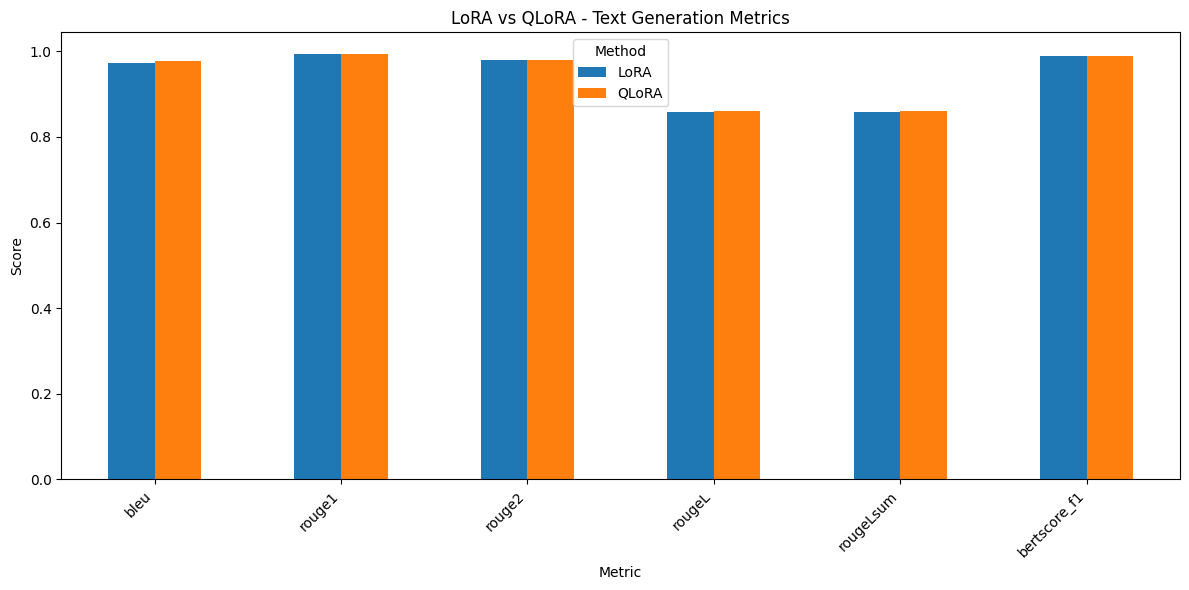

Saved: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison/01_text_generation_metrics.png


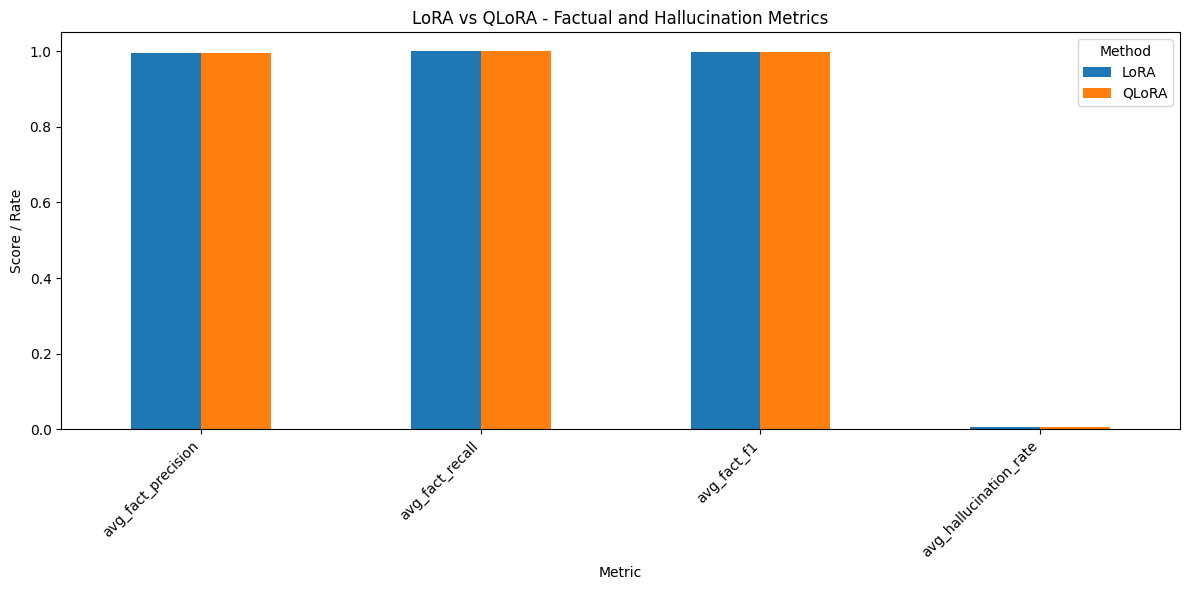

Saved: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison/02_factual_hallucination_metrics.png


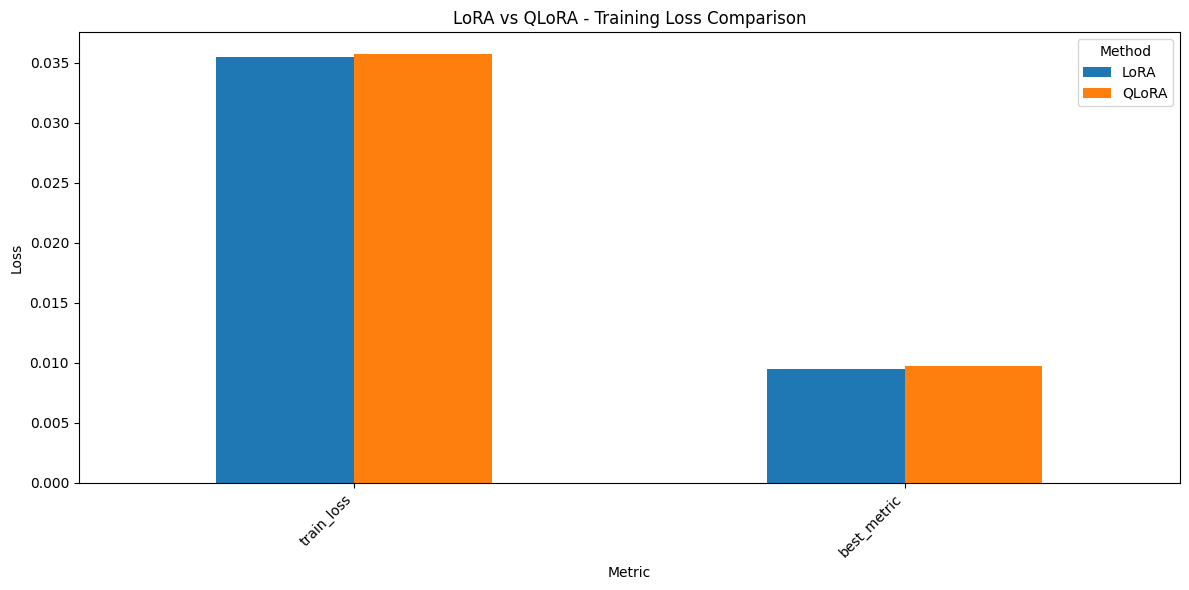

Saved: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison/03_training_loss_metrics.png


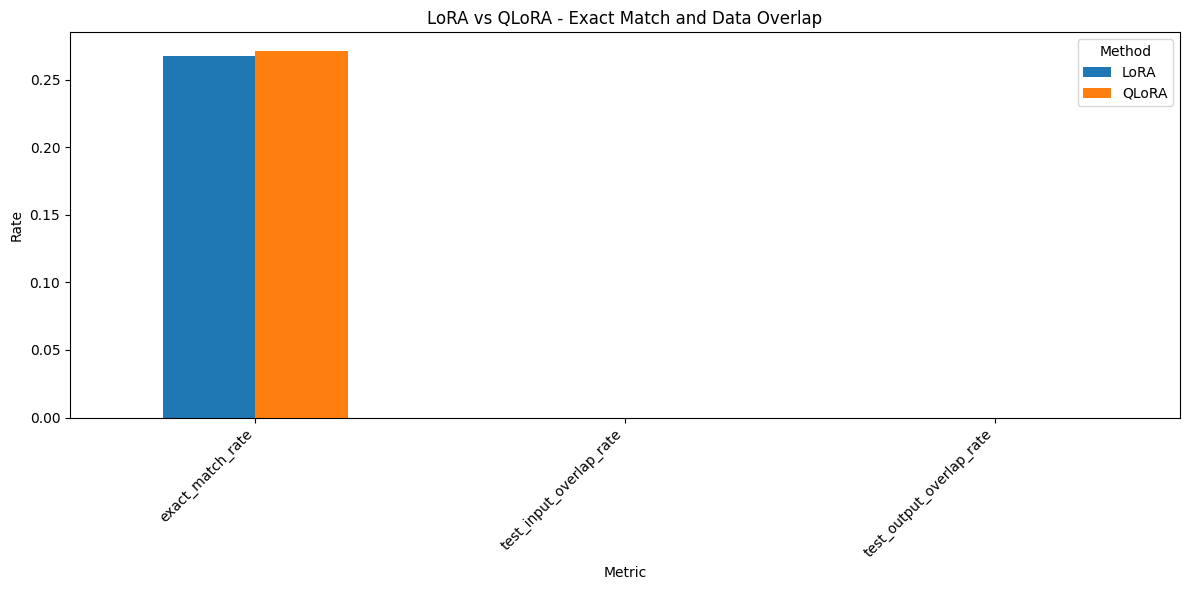

Saved: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison/04_exact_match_overlap.png


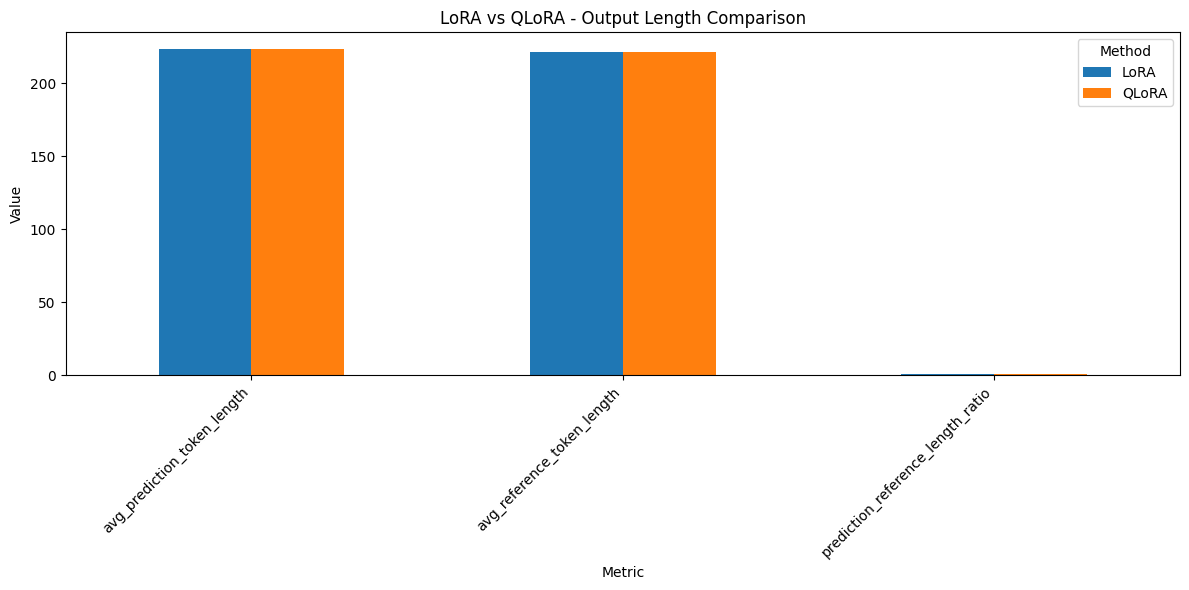

Saved: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison/05_output_length_comparison.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

#SAVE DIR
save_dir = "/content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/model_comparison"
os.makedirs(save_dir, exist_ok=True)

# If comparison_df is already in memory, this will use it.
# Otherwise reload from saved file.
if "comparison_df" not in globals():
    comparison_df = pd.read_csv(os.path.join(save_dir, "lora_vs_qlora_full_comparison.csv"))

comparison_df = comparison_df.copy()

# ensure method column exists and is clean
comparison_df["method"] = comparison_df["method"].astype(str)

#HELPER FOR BAR CHARTS
def plot_metric_bar(metric_names, title, filename, ylabel="Score"):
    available = [m for m in metric_names if m in comparison_df.columns]
    if not available:
        print(f"Skipped {title}: no matching metrics found.")
        return

    plot_df = comparison_df[["method"] + available].set_index("method").T

    ax = plot_df.plot(kind="bar", figsize=(12, 6))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Metric")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Method")
    plt.tight_layout()

    out_path = os.path.join(save_dir, filename)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

#TEXT GENERATION METRICS
plot_metric_bar(
    metric_names=["bleu", "rouge1", "rouge2", "rougeL", "rougeLsum", "bertscore_f1"],
    title="LoRA vs QLoRA - Text Generation Metrics",
    filename="01_text_generation_metrics.png",
    ylabel="Score"
)

#FACTUAL / HALLUCINATION METRICS
plot_metric_bar(
    metric_names=["avg_fact_precision", "avg_fact_recall", "avg_fact_f1", "avg_hallucination_rate"],
    title="LoRA vs QLoRA - Factual and Hallucination Metrics",
    filename="02_factual_hallucination_metrics.png",
    ylabel="Score / Rate"
)

#TRAINING / FIT METRICS
plot_metric_bar(
    metric_names=["train_loss", "best_metric"],
    title="LoRA vs QLoRA - Training Loss Comparison",
    filename="03_training_loss_metrics.png",
    ylabel="Loss"
)

#EXACT MATCH + OVERLAP
plot_metric_bar(
    metric_names=["exact_match_rate", "test_input_overlap_rate", "test_output_overlap_rate"],
    title="LoRA vs QLoRA - Exact Match and Data Overlap",
    filename="04_exact_match_overlap.png",
    ylabel="Rate"
)

#OUTPUT LENGTH COMPARISON
plot_metric_bar(
    metric_names=["avg_prediction_token_length", "avg_reference_token_length", "prediction_reference_length_ratio"],
    title="LoRA vs QLoRA - Output Length Comparison",
    filename="05_output_length_comparison.png",
    ylabel="Value"
)